In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)

In [ ]:
dtypes = df.dtypes
n_unique = df.nunique()
pd.DataFrame({"Dtype": dtypes, "num_unique": n_unique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
num_unique,2,3,2,88,7,7,248,147,3


In [ ]:
from preproccessing.chk_type import check_type
check_type(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Dtype,category,category,category,float64,category,category,float64,category
num_unique,2,3,2,65,7,7,204,3


In [ ]:
cols = ['Survived','Pclass','Sex','SibSp','Parch','Embarked']
df[cols] = df[cols].astype('category')

In [ ]:
from preproccessing.chk_type import check_type
check_type(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Dtype,category,category,category,float64,category,category,float64,category
num_unique,2,3,2,65,7,7,204,3


In [ ]:
def handle_types(cols):
    df[cols] = df[cols].astype('category')
    chk_type(df)

In [ ]:
null = df.isnull().sum()
ratio =null/df.shape[0]
pd.DataFrame({"NULL": null, "ratio": ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
NULL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
df = df.dropna(subset = ['Embarked'])   #DROP RAWS

In [ ]:
median = df['Age'].median()
df.fillna({'Age': median}, inplace=True)

null = df.isnull().sum()
ratio = null/df.shape[0]
pd.DataFrame({"NULL": null, "ratio": ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
NULL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.dtypes

Survived    category
Pclass      category
Sex         category
Age          float64
SibSp       category
Parch       category
Fare         float64
Embarked    category
dtype: object

In [ ]:
num_cols = ['Age','Fare']

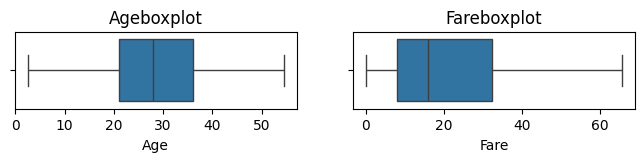

In [ ]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i,col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient = 'h')
    plt.title(f"{col}boxplot")
plt.show()

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)   #quantile automatic calculate Q2
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 -1.5*IQR
    upper_fence = Q3 + 1.5*IQR
    lower_Outliers = df[df[col]<lower_fence][col].values
    upper_Outliers = df[df[col]>upper_fence][col].values
    df.replace(
        {col: dict.fromkeys(df.loc[df[col] < lower_fence, col], lower_fence)},
        inplace=True
    )

    df.replace(
        {col: dict.fromkeys(df.loc[df[col] > upper_fence, col], upper_fence)},
        inplace=True
    )

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

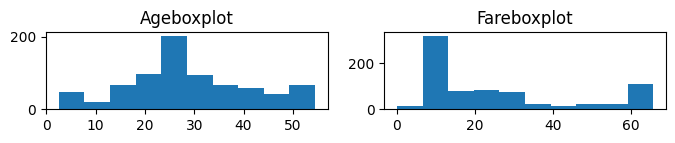

In [ ]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i,col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col])
    plt.title(f"{col}boxplot")
plt.show()

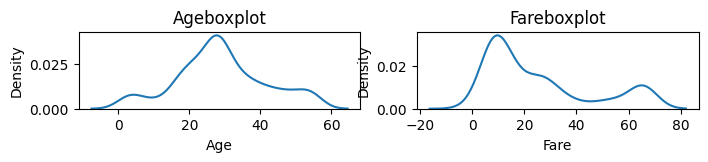

In [ ]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i,col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col}boxplot")
plt.show()

In [ ]:
cat_cols = df.select_dtypes('category').columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

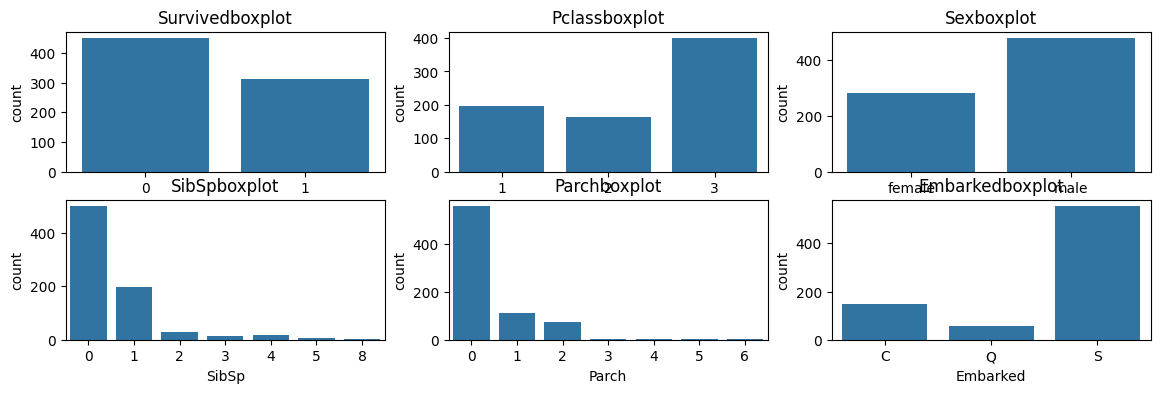

In [ ]:
cat_cols = df.select_dtypes('category').columns
plt.figure(figsize=(14,4))
for i,col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col,data = df)
    plt.title(f"{col}boxplot")
plt.show()